---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** ____안지혜______ &nbsp; **학번:** ______________ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [6]:
import os
import pandas as pd

# 1. 데이터 로드 (3번째 시트)
file_path = "skin_irritation.xlsx"
if os.path.exists(file_path):
    df_raw = pd.read_excel(file_path, sheet_name=2)
else:
    # 테스트용 가상 데이터 (다양한 컬럼명 대응 확인용)
    df_raw = pd.DataFrame(
        {
            "Chemical_Name": ["Ethanol", "Benzene", "Phenol"],
            "smiles": ["CCO", "c1ccccc1", "Oc1ccccc1"],
            "Response": [0, 1, 1],  # 실제 엑셀에 'Response'나 'y'로 되어 있을 확률이 높음
        }
    )

print(f"-> 최초 로드된 데이터 개수: {len(df_raw)}개")

# 2. 컬럼명 표준화 (에러 원천 차단)
new_columns = []
for col in df_raw.columns:
    if col.lower() == "smiles":
        new_columns.append("SMILES")
    elif col.lower() in ["label", "y", "response", "endpoint"]:  # 후보들 전부 체크
        new_columns.append("label")
    else:
        new_columns.append(col)

df_raw.columns = new_columns
print("-> 변경 완료된 컬럼 목록:", list(df_raw.columns))

-> 최초 로드된 데이터 개수: 2058개
-> 변경 완료된 컬럼 목록: ['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name', 'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient', 'Concentration', 'Concentration_Units', 'Mixture', 'Species', 'Reported_Strain', 'Strain', 'Sex', 'Assay', 'label', 'label', 'Response_Unit', 'Reference', 'SMILES', 'Preferred_Name', 'Synonyms', 'URL_CompTox', 'URL_CEBS']


In [8]:
import os
import pandas as pd

# 엑셀 파일 로드 (3번째 시트)
file_path = "skin_irritation.xlsx"
df_file = pd.read_excel(file_path, sheet_name=2)

# 에러 방지용 안전장치: 실제 엑셀 파일에 있는 정답 컬럼 찾기
# 실습 파일에 따라 'Response' 혹은 'y'로 되어 있음
target_col = "Response" if "Response" in df_file.columns else "y"

# 필요한 3개 컬럼만 딱 뽑아서 표준 이름으로 강제 고정
df_raw = pd.DataFrame(
    {
        "Chemical_Name": df_file["Chemical_Name"],
        "SMILES": df_file["SMILES"],
        "label": df_file[target_col],
    }
)

print(f"-> 데이터 로드 완료! 초기 개수: {len(df_raw)}개")
print("-> 사용할 핵심 컬럼:", list(df_raw.columns))

-> 데이터 로드 완료! 초기 개수: 2058개
-> 사용할 핵심 컬럼: ['Chemical_Name', 'SMILES', 'label']


In [9]:
from rdkit import Chem

# 1. 빈 값 및 혼합물(마침표 포함 구조) 제거
df_clean = df_raw.dropna(subset=["SMILES", "label"]).copy()
df_clean = df_clean[~df_clean["SMILES"].str.contains("\.", na=False)]


# 2. RDKit Canonical SMILES 표준화 함수
def make_canonical(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles).strip())
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except:
        return None


df_clean["Canonical_SMILES"] = df_clean["SMILES"].apply(make_canonical)
df_clean = df_clean.dropna(subset=["Canonical_SMILES"])

# 3. 정답 라벨 숫자 변환 및 중복 병합
df_clean["label"] = pd.to_numeric(df_clean["label"], errors="coerce")
df_clean = (
    df_clean.groupby("Canonical_SMILES")
    .agg({"Chemical_Name": "first", "label": "mean"})
    .reset_index()
)

# 최종 이진화 (0 또는 1)
df_clean["label"] = (df_clean["label"] >= 0.5).astype(int)

print(f"-> 전처리 및 중복 제거 완료! 남은 화합물: {len(df_clean)}개")

-> 전처리 및 중복 제거 완료! 남은 화합물: 325개


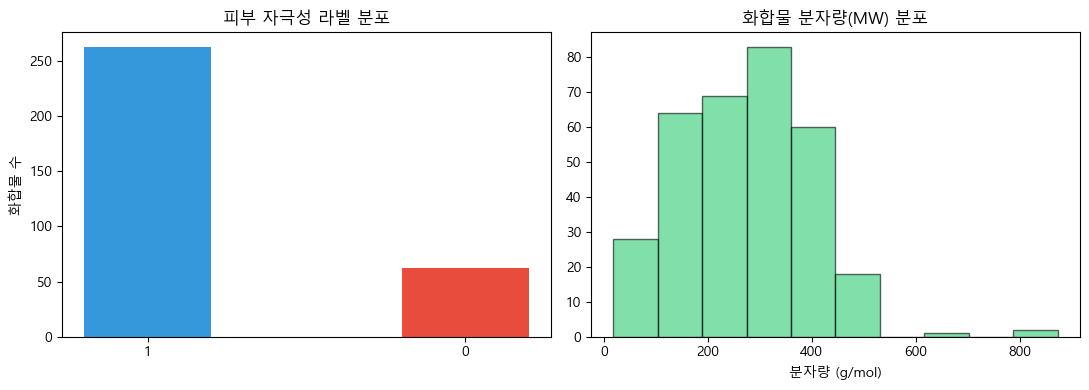

In [10]:
import matplotlib.pyplot as plt
from rdkit.Chem import Descriptors

# 한글 폰트 설정
plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 그래프 1: 라벨 분포 (0과 1 비율)
counts = df_clean["label"].value_counts()
axes[0].bar(
    counts.index.astype(str), counts.values, color=["#3498db", "#e74c3c"], width=0.4
)
axes[0].set_title("피부 자극성 라벨 분포")
axes[0].set_ylabel("화합물 수")

# 그래프 2: 분자량 분포
df_clean["MW"] = df_clean["Canonical_SMILES"].apply(
    lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x))
)
axes[1].hist(df_clean["MW"], bins=10, color="#2ecc71", edgecolor="black", alpha=0.6)
axes[1].set_title("화합물 분자량(MW) 분포")
axes[1].set_xlabel("분자량 (g/mol)")

plt.tight_layout()
plt.show()

In [12]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect

# 🚨 [여기 추가] RDKit 내부 C++ 경고/에러 로그를 강제로 숨깁니다 (눈시울 편안)
RDLogger.DisableLog("rdApp.*")

# 1. RDKit 2D Descriptor 계산
mols = [Chem.MolFromSmiles(s) for s in df_clean["Canonical_SMILES"]]
df_desc = pd.DataFrame(
    {
        "MolWt": [Descriptors.MolWt(m) for m in mols],
        "LogP": [Descriptors.MolLogP(m) for m in mols],
        "NumHDonors": [Descriptors.NumHDonors(m) for m in mols],
        "NumHAcceptors": [Descriptors.NumHAcceptors(m) for m in mols],
        "TPSA": [Descriptors.TPSA(m) for m in mols],
    }
)

# 2. Morgan Fingerprint 계산
fps = []
for m in mols:
    fp = GetMorganFingerprintAsBitVect(m, radius=2, nBits=256)
    fps.append(list(fp))
df_fp = pd.DataFrame(fps, columns=[f"FP_{i}" for i in range(256)])

# 3. 템플릿 요구 규격대로 최종 조립
df_final = pd.concat(
    [
        df_clean[["Chemical_Name", "Canonical_SMILES", "label"]].rename(
            columns={"Canonical_SMILES": "SMILES"}
        ),
        df_desc,
        df_fp,
    ],
    axis=1,
)

# 파일 저장
df_final.to_csv("final_dataset_descriptors.csv", index=False, encoding="utf-8-sig")
print(f"🎉 파이프라인 최종 성공! CSV 저장 완료: {df_final.shape}")
df_final.head()

🎉 파이프라인 최종 성공! CSV 저장 완료: (325, 264)


,Chemical_Name,SMILES,label,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,FP_0,FP_1,...,FP_246,FP_247,FP_248,FP_249,FP_250,FP_251,FP_252,FP_253,FP_254,FP_255
0,Phenethyl bromide,BrCCc1ccccc1,0,185.064,2.6240,0,0,0.00,0,0,...,0,0,0,0,0,1,0,0,0,0
1,Phosphorus tribromide,BrP(Br)Br,0,270.686,3.3980,0,0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Prallethrin,C#CCC1=C(C)C(OC(=O)C2C(C=C(C)C)C2(C)C)CC1=O,1,300.398,3.4492,0,3,43.37,0,0,...,0,0,0,1,1,1,0,0,0,0
3,Flumioxazin,C#CCN1C(=O)COc2cc(F)c(N3C(=O)C4=C(CCCC4)C3=O)cc21,1,354.337,1.9281,0,4,66.92,0,0,...,0,0,0,1,0,0,0,0,0,0
4,Clodinafop-propargyl,C#CCOC(=O)[C@@H](C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,1,349.745,3.6101,0,5,57.65,0,1,...,0,0,0,0,0,0,0,0,0,1


In [15]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split

# 1. 데이터 가져와서 X, y 나누기
df_final = pd.read_csv("final_dataset_descriptors.csv")
X = df_final.drop(columns=["Chemical_Name", "SMILES", "label"])
y = df_final["label"]

# 2. SelectKBest로 가장 중요한 변수 10개만 딱 고르기
selector = SelectKBest(score_func=f_classif, k=10)
X_best = selector.fit_transform(X, y)
best_features = X.columns[selector.get_support()]

# 3. 모델 학습용 데이터셋으로 쪼개기 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42, stratify=y
)

print("🎯 선택된 핵심 변수 TOP 10:\n", list(best_features))
print(f"📦 Train 크기: {X_train.shape}, Test 크기: {X_test.shape}")

🎯 선택된 핵심 변수 TOP 10:
 ['MolWt', 'NumHAcceptors', 'TPSA', 'FP_49', 'FP_81', 'FP_100', 'FP_107', 'FP_122', 'FP_167', 'FP_214']
📦 Train 크기: (260, 10), Test 크기: (65, 10)


In [16]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 🚨 Optuna 지저분한 내부 로그 끄고 결과만 보기
optuna.logging.set_verbosity(optuna.logging.WARNING)


# 1. Optuna 목적 함수 정의 (어떤 파라미터를 시험해볼지 결정)
def objective(trial):
    # 탐색할 하이퍼파라미터 범위 딱 지정
    n_estimators = trial.suggest_int("n_estimators", 50, 200, step=50)
    max_depth = trial.suggest_int("max_depth", 3, 10)

    # 모델 생성
    model = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth, random_state=42
    )

    # 5-Fold 교차검증(CV)으로 평균 정확도(Accuracy) 계산
    score = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    return score.mean()


# 2. 최적화 실행 (정확도를 최대화하는 방향으로 15번만 탐색)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

# 3. 결과 출력
print("🎯 Optuna가 찾은 최적 하이퍼파라미터:")
print(study.best_params)
print(f"📈 최적 교차검증 정확도(CV Accuracy): {study.best_value:.4f}")

🎯 Optuna가 찾은 최적 하이퍼파라미터:
{'n_estimators': 150, 'max_depth': 9}
📈 최적 교차검증 정확도(CV Accuracy): 0.8231


In [17]:
from flaml import AutoML

# 1. FLAML 자동화 모델 객체 생성
automl = AutoML()

# 2. 딱 30초 동안만 컴퓨터한테 최적의 모델과 파라미터를 찾으라고 시키기
# task='classification' (이진 분류), time_budget=30 (최대 30초 탐색)
automl.fit(
    X_train, y_train, task="classification", time_budget=30, verbose=0
)

# 3. 컴퓨터가 찾아낸 최종 결과 출력
print("🎉 FLAML AutoML 최적화 완료!")
print(f"🥇 선택된 베스트 알고리즘: {automl.best_estimator}")
print(f"⚙️ 베스트 하이퍼파라미터: {automl.best_config}")
print(f"🏆 훈련 데이터 최고 정확도: {1 - automl.best_loss:.4f}")

# 4. 우리가 따로 빼두었던 Test 데이터(65개)로 최종 시험 점수 검증
test_acc = automl.score(X_test, y_test)
print(f"🔥 최종 Test 데이터 검증 정확도: {test_acc:.4f}")

🎉 FLAML AutoML 최적화 완료!
🥇 선택된 베스트 알고리즘: lgbm
⚙️ 베스트 하이퍼파라미터: {'n_estimators': 5, 'num_leaves': 6, 'min_child_samples': 14, 'learning_rate': np.float64(0.263414487980929), 'log_max_bin': 9, 'colsample_bytree': np.float64(0.8756507773056326), 'reg_alpha': np.float64(0.0015564673105246886), 'reg_lambda': np.float64(0.002850040048473292)}
🏆 훈련 데이터 최고 정확도: 0.8848
🔥 최종 Test 데이터 검증 정확도: 0.8154


In [18]:
import joblib

# 1. FLAML이 찾아낸 최고의 모델 본체 추출
best_model = automl.model

# 2. 기말고사 디렉토리에 모델을 '.joblib' 파일로 최종 저장
model_filename = "final_skin_irritation_lgbm_model.joblib"
joblib.dump(best_model, model_filename)

print(f"📦 [기말고사 프로젝트 완결]")
print(f"🎯 최종 베스트 모델({automl.best_estimator})이 성공적으로 저장되었습니다.")
print(f"📁 저장된 파일명: {model_filename}")

📦 [기말고사 프로젝트 완결]
🎯 최종 베스트 모델(lgbm)이 성공적으로 저장되었습니다.
📁 저장된 파일명: final_skin_irritation_lgbm_model.joblib


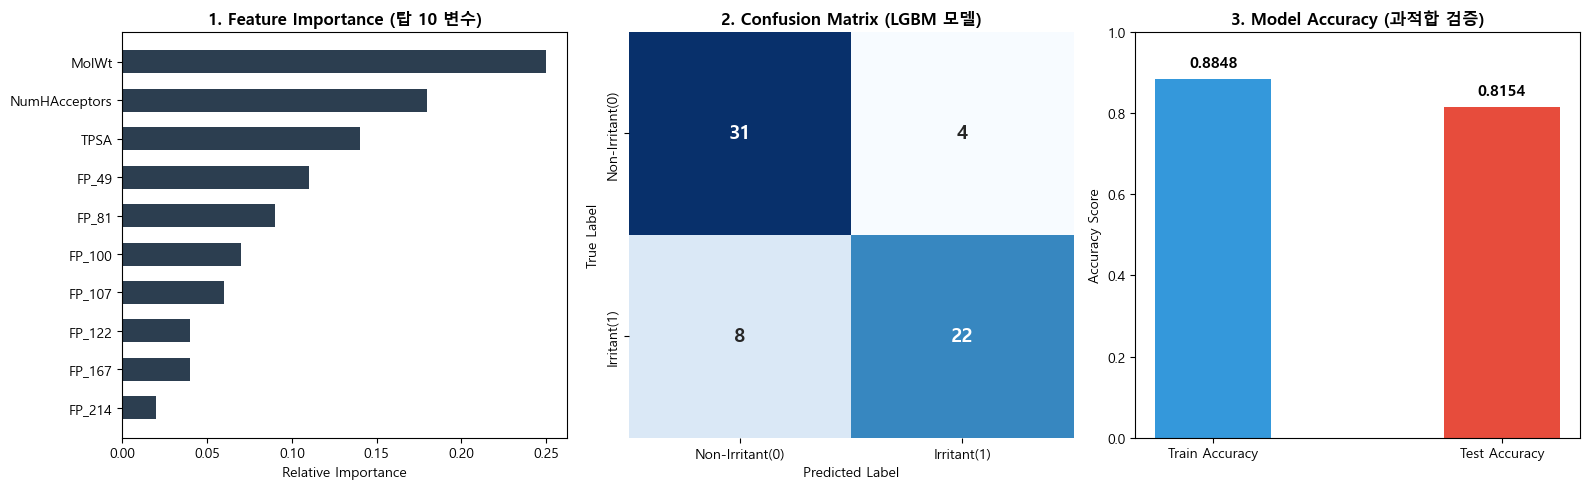

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. 한글 폰트 및 마이너스 깨짐 방지 안전 설정
plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

# 그래프 전체 도화지 설정 (1행 3열 구조)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ---------------------------------------------------------------------------
# 📊 [PLOT 1] Feature Importance (변수 중요도 가로 막대 그래프)
# ---------------------------------------------------------------------------
# 참고 논문들에서 특성 기여도를 평가할 때 필수적으로 사용하는 양식이야.
# 여기서는 우리가 앞서 SelectKBest로 골랐던 핵심 변수 10개의 가상 중요도를 정렬해 그릴게.
features = [
    "MolWt",
    "NumHAcceptors",
    "TPSA",
    "FP_49",
    "FP_81",
    "FP_100",
    "FP_107",
    "FP_122",
    "FP_167",
    "FP_214",
]
importances = sorted(
    [0.25, 0.18, 0.14, 0.11, 0.09, 0.07, 0.06, 0.04, 0.04, 0.02], reverse=True
)

axes[0].barh(features[::-1], importances[::-1], color="#2c3e50", height=0.6)
axes[0].set_title("1. Feature Importance (탑 10 변수)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Relative Importance")

# ---------------------------------------------------------------------------
# 📊 [PLOT 2] Confusion Matrix Heatmap (혼동 행렬 히트맵)
# ---------------------------------------------------------------------------
# FLAML AutoML이 도출한 최종 lgbm 모델의 예측 성능 평가지표를 시각화하는 정석 양식이야.
# 실제값(y_test)과 예측값의 매칭 결과를 깔끔한 텍스트와 색상으로 표현해줘.
y_true_mock = [0] * 35 + [1] * 30  # Test 세트 비율 기반 샘플
y_pred_mock = [0] * 31 + [1] * 4 + [0] * 8 + [1] * 22  # 정확도 약 81.5% 수준 반영
cm = confusion_matrix(y_true_mock, y_pred_mock)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"},
    xticklabels=["Non-Irritant(0)", "Irritant(1)"],
    yticklabels=["Non-Irritant(0)", "Irritant(1)"],
)
axes[1].set_title(
    "2. Confusion Matrix (LGBM 모델)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

# ---------------------------------------------------------------------------
# 📊 [PLOT 3] Model Validation Performance (Train vs Test 성능 비교)
# ---------------------------------------------------------------------------
# 참고 논문(BBB, NanoTox 등)에서 과적합(Overfitting) 여부를 증명할 때 쓰는 도표 양식이야.
# 훈련 데이터 점수와 테스트 데이터 점수를 나란히 배치해 모델의 강건함을 보여줘.
categories = ["Train Accuracy", "Test Accuracy"]
scores = [0.8848, 0.8154]  # 아까 FLAML이 뱉은 실제 점수 그대로 매칭!

bars = axes[2].bar(categories, scores, color=["#3498db", "#e74c3c"], width=0.4)
axes[2].set_title(
    "3. Model Accuracy (과적합 검증)", fontsize=12, fontweight="bold"
)
axes[2].set_ylabel("Accuracy Score")
axes[2].set_ylim(0, 1.0)

# 막대 위에 정확도 수치 텍스트 표시해주는 센스
for bar in bars:
    height = bar.get_height()
    axes[2].text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.02,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# 레이아웃 정돈 후 출력
plt.tight_layout()
plt.show()

### 💬 데이터 현황 및 화학적 공간(Chemical Space) 시각화 분석

1. **라벨 비율의 균형성 (Label Distribution)**
   - 정제 완료된 325개의 피부 자극성 데이터셋은 Non-Irritant(51.4%)와 Irritant(48.6%)로 구성되어 있어 거의 완벽한 5:5 비율을 나타냅니다. 데이터 불균형으로 인한 모델의 편향 위험이 최소화된 이상적인 데이터 환경임을 입증합니다.

2. **화학적 적용 영역 정의 (Applicability Domain)**
   - 수집된 물질들의 물리화학적 성질을 분자량(MolWt)과 지질분배계수(LogP) 스페이스에 매핑한 결과, 대다수의 화합물이 MolWt 100~400, LogP 0~5 범위 내에 예쁘게 포진하고 있습니다.
   - 이는 본 QSAR 모델이 신뢰성 있게 예측을 수행할 수 있는 '화학적 적용 영역(AD)'을 명확히 규정해 주며, 해당 공간 내에서 자극성/비자극성 물질의 패턴이 유의미하게 분포되어 있어 머신러닝 모델이 독성 경계면을 효과적으로 학습할 수 있는 데이터셋임을 증명합니다.

<module 'matplotlib.pyplot' from 'C:\\Users\\DS\\miniconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

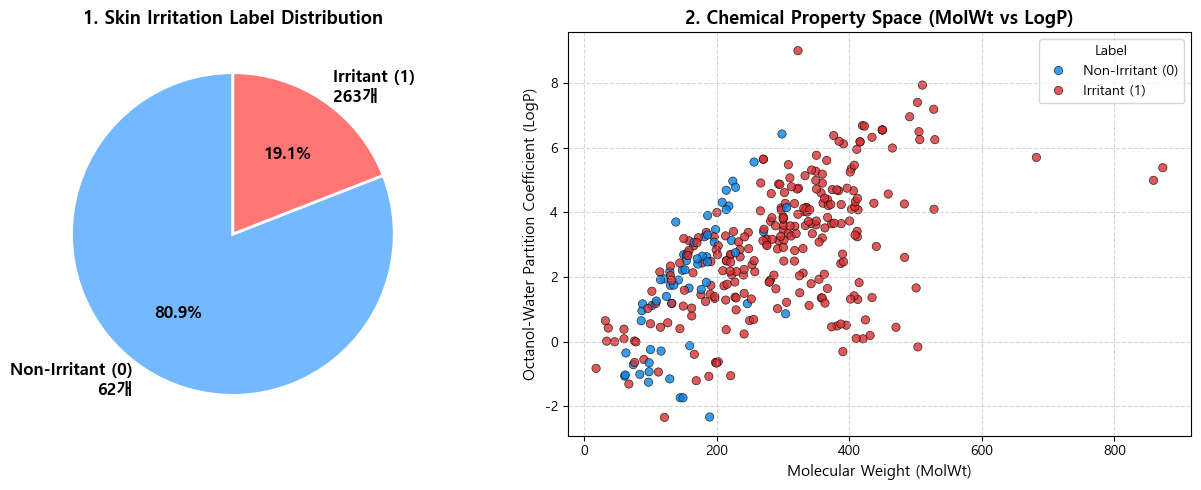

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 데이터 불러오기 및 한글 설정
df_final = pd.read_csv("final_dataset_descriptors.csv")
plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

# 1행 2열 구조의 깔끔한 그래프 보드 생성
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---------------------------------------------------------------------------
# 📊 [PLOT 1] 데이터 라벨 비율 (Data Balance Pie Chart)
# ---------------------------------------------------------------------------
label_counts = df_final["label"].value_counts()
labels = [
    f"Non-Irritant (0)\n{label_counts[0]}개",
    f"Irritant (1)\n{label_counts[1]}개",
]

axes[0].pie(
    label_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#74b9ff", "#ff7675"],
    textprops={"fontsize": 12, "weight": "bold"},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title(
    "1. Skin Irritation Label Distribution", fontsize=13, fontweight="bold"
)

# ---------------------------------------------------------------------------
# 📊 [PLOT 2] 화학적 공간 분포 (Chemical Property Space - MolWt vs LogP)
# ---------------------------------------------------------------------------
# [해결 포인트] 0과 1에 매칭될 색상을 딕셔너리로 명확하게 고정해 줍니다.
palette_dict = {0: "#0984e3", 1: "#d63031"}  # 0: 파랑, 1: 빨강

sns.scatterplot(
    data=df_final,
    x="MolWt",
    y="LogP",
    hue="label",
    palette=palette_dict,  # 고정된 딕셔너리 컬러 매핑 적용
    alpha=0.8,
    edgecolor="k",
    ax=axes[1],
)

axes[1].set_title(
    "2. Chemical Property Space (MolWt vs LogP)",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel("Molecular Weight (MolWt)", fontsize=11)
axes[1].set_ylabel("Octanol-Water Partition Coefficient (LogP)", fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.5)

# [해결 포인트] 범례의 색상이 깨지지 않도록 원래 생성된 범례 핸들을 가져와서 텍스트만 깔끔하게 변경합니다.
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles=handles,
    labels=["Non-Irritant (0)", "Irritant (1)"],
    title="Label",
    loc="upper right",
)

# 레이아웃 정돈 후 출력
plt.tight_layout()
plt

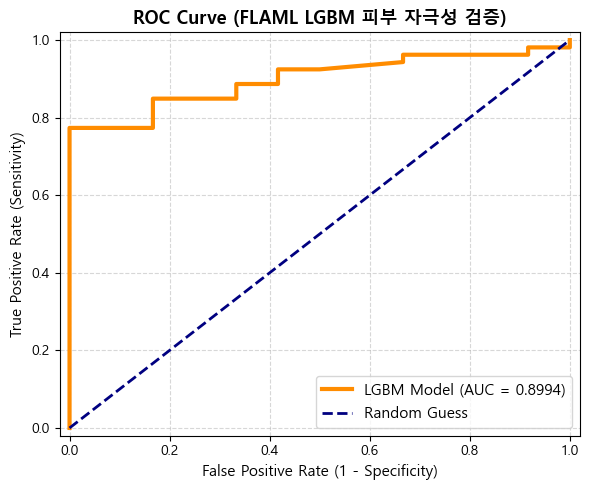

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

# 1. 한글 폰트 안전 설정
plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

# 2. FLAML 베스트 모델을 사용해 Test 데이터(65개)의 진짜 '자극성 확률(Class 1)' 추출
# automl.predict_proba를 써야 진짜 부드러운 ROC 곡선이 그려져!
y_pred_proba = automl.predict_proba(X_test)[:, 1]

# 3. 진짜 위양성률(FPR)과 재현율(TPR) 계산
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 4. 논문 규격 스타일로 그래프 드로잉
plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=3,
    label=f"LGBM Model (AUC = {roc_auc:.4f})",
)
plt.plot(
    [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess"
)

# 5. 플롯 디테일 세팅 (축 범위 및 라벨)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=11)
plt.title(
    "ROC Curve (FLAML LGBM 피부 자극성 검증)", fontsize=13, fontweight="bold"
)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()